In [4]:
# !pip install ipykernal
# !pip install matplotlib
# !pip install scipy

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider,Button,RadioButtons
from scipy.stats import norm

In [ ]:
def call_payoff(s,k,premium=0.0,qty=1.0,long=True):
    """
    s: spot price \n
    k: strick price \n
    premium: one lot price \n
    qty: number of lots \n
    """
    payoff = np.maximum(s - k, 0) - premium
    return payoff * qty if long else -payoff * qty

In [8]:
def put_payoff(s,k,premium=0.0,qty=1.0,long=True):
    """
    s: spot price \n
    k: strick price \n
    premium: one lot price \n
    qty: number of lots \n
    """
    payoff = np.maximum(k - s, 0) - premium
    return payoff * qty if long else -payoff * qty

In [9]:
def combined_payoff(s, legs):
    total = np.zeros_like(s)
    for leg in legs:
        if leg['type'] == 'C':
            total += call_payoff(s,leg['K'],premium=leg['premium'],qty=leg['qty'],long=leg['long'])
        else:
            total += put_payoff(s,leg['K'],premium=leg['premium'],qty=leg['qty'],long=leg['long'])
    return total

In [10]:
##Monte Carlo GBM simulator for S_T

def simulate_st(S0,mu,sigma,T_days,n_sims=12000,seed=42):
    """
    S0: Spot price at t=0(current spopt price) \n
    mu: avg \n
    sigma: volitality \n
    T_days: days to Expiry \n
    n_sims: Number of simmulation \n
    seed : random state
    """
    np.random.seed(seed)
    T = max(T_days,0)/252.0
    if T == 0:
        return np.array([S0])
    drift = (mu - 0.5*sigma **2) * T
    diffusion = sigma *np.sqrt(T) * np.random.random(n_sims)
    ST = S0 * np.exp(drift + diffusion)
    return ST



def expected_matrics_via_mc(legs,S0,mu,sigma,T_days,n_sims=12000):
    ST = simulate_st(S0,mu,sigma,T_days,n_sims=12000,seed=42)
    sim_payoff = np.array([combined_payoff(np.array([s]),legs)[0] for s in ST])
    ev = sim_payoff.mean()
    prob_profit = (sim_payoff > 0).mean()
    median = np.median(sim_payoff)
    downside_pct = (sim_payoff < 0).mean()
    return {'ev':ev, 'prob_profit':prob_profit, 'median':median, 'downside_pct':downside_pct}

In [11]:
### Analytics helpers
def breakevens(S,payoff):
    signs = np.sign(payoff)
    idx = np.where(np.diff(signs) != 0)[0]
    be_points = []
    for i in idx:
        x0, x1 = S[i], S[i+1]
        y0, y1 = payoff[i], payoff[i+1]
        if(y1 -y0) == 0:
            be = x0
        else:
            be = x0 - y0 * (x1 - x0) / (y1 - y0)
        be_points.append(be)
    return be_points 

In [12]:
mu_default = 0.06
S0_default =  24900
strike_default = 25000
premium_call_default = 380.0
premium_put_default = 360.0
qty_default = 1.0
T_days_default = 9
sigma_default = 0.18

S_min_default = S0_default - 5000
S_max_default =  S0_default + 5000
S = np.linspace(S_min_default,S_max_default,400)

In [19]:
### Create initial legs (Straddle)
def make_straddle(K, p_call, p_put, qty):
    return [
        {'type':'C','K':K,'premium':p_call,'qty':qty,'long':True},
        {'type':'P','K':K,'premium':p_put,'qty':qty,'long':True}
    ]

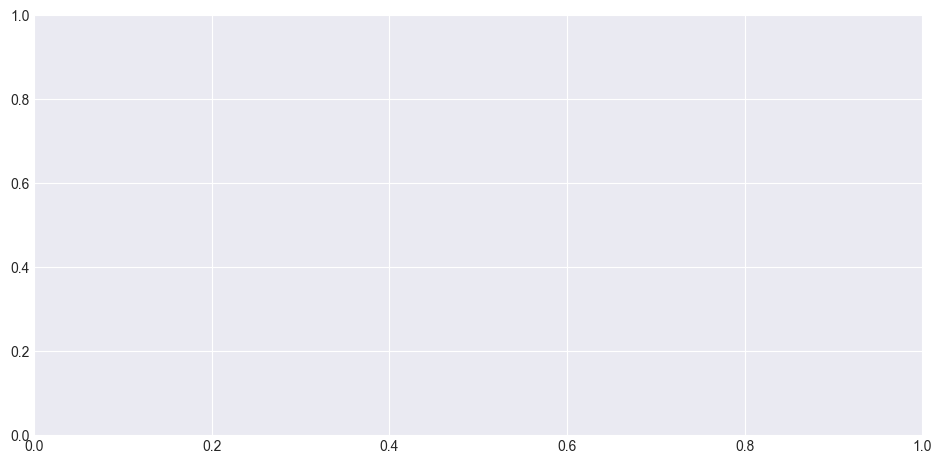

In [16]:
### Plot and widgets setup
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize= (12,7))
plt.subplots_adjust(left=0.19, bottom=0.28, right=0.93)

In [20]:
### initial payoff line
legs = make_straddle(strike_default,premium_call_default,premium_put_default, qty_default)
payoff = combined_payoff(S,legs)
line_payoff, = ax.plot(S, payoff, lw=2, label ='Long Straddle')

ax.axhline(0,color='k',lw=1)
ax.set_xlabel("Underlying Price at Expiry")
ax.set_ylabel("Profit / Loss per unit")
ax.set_title("Enteractive Oprions Strategy Payoff + Monte Carlo Metrics")
ax.legend(loc='upper left')

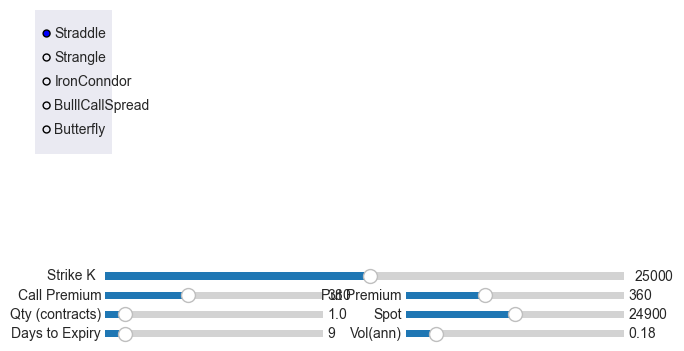

In [21]:
### vertical spot line & annotatio text  postitions
vline = ax.axvline(S0_default, color='red', linestyle='--',lw=1.5)
spot_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va = 'top')
be_text = ax.text(0.02,0.88, "", transform=ax.transAxes, va = 'top')
mc_text = ax.text(0.02, 0.78, "", transform=ax.transAxes, va = 'top')

#filled areas
pos_fill = ax.fill_between(S, payoff, where=(payoff >= 0),interpolate=True, alpha=0.25)
neg_fill = ax.fill_between(S, payoff, where=(payoff < 0),interpolate=True, alpha=0.25, color='tomato')

# slider axes layout
axstrike = plt.axes([0.12,0.13,0.81,0.03])
axpcall = plt.axes([0.12,0.09,0.34,0.03])
axpput = plt.axes([0.59,0.09,0.34,0.03])
axqty = plt.axes([0.12,0.05,0.34,0.03])
axspot = plt.axes([0.59,0.05,0.34,0.03])
axT = plt.axes([0.12,0.01,0.34,0.03])
axvol = plt.axes([0.59,0.01,0.34,0.03])

s_strike = Slider(axstrike,'Strike K',S_min_default,S_max_default,valinit=strike_default,valstep=50)
s_pcall = Slider(axpcall, 'Call Premium', 0.0, 1000.0, valinit=premium_call_default)
s_pput = Slider(axpput, 'Put Premium', 0.0,1000.0, valinit=premium_put_default)
s_qty = Slider(axqty, 'Qty (contracts)', 0.1, 10.0, valinit=qty_default)
s_spot = Slider(axspot, 'Spot', S_min_default,S_max_default,valinit=S0_default)
s_T = Slider(axT, 'Days to Expiry', 1, 90, valinit=T_days_default,valstep=1)
s_vol = Slider(axvol, 'Vol(ann)', 0.05,1.0, valinit=sigma_default)


###Radiobuttons for strategy selection (mutually exclusive)
axradio = plt.axes([0.01,0.4,0.12,0.30])
radio = RadioButtons(axradio, ('Straddle','Strangle', 'IronConndor','BulllCallSpread','Butterfly'))
radio.set_active(0)

In [22]:
### Update logic
def build_strategy_from_radio(K, p_call, p_put, qty):
    strategy = radio.value_selected
    if strategy  == 'Straddle':
        return make_straddle(K,p_call,p_put,qty), 'Long Straddle'
    elif strategy == 'Strangle':
        Kput = max(1,K-400)
        Kcall = K + 400
        legs = [
            {'type':'C','K':Kcall,'premium':p_call*0.6,'qty':qty,'long':True},
            {'type':'P','K':Kput,'premium':p_put*0.6,'qty':qty,'long':True}
        ]
        return legs, f'Long Strangle({Kput}/{Kcall})'
    elif strategy == 'IrronCondor':
        legs = [
            
            {'type':'P','K':K-400,'premium':p_put*0.7,'qty':qty,'long':False},  #short put
            {'type':'P','K':K-800,'premium':p_put*0.3,'qty':qty,'long':True},  #long put
            {'type':'C','K':K-400,'premium':p_call*0.7,'qty':qty,'long':False}, #short call
            {'type':'C','K':K-800,'premium':p_call*0.3,'qty':qty,'long':True}  #long call
        ]
        return legs, 'Iron Condor (synthatic levels)'
    elif strategy == 'BullCallSpread':
        width = 400
        K_buy = max(1, K - int(width/2)) ##lower strike
        K_sell = K_buy + width  ## higher strike
        legs = [
            {'type':'C','K':K_buy,'premium':p_call*0.9,'qty':qty,'long':True}, #buy lower call
            {'type':'C','K':K_sell,'premium':p_call*0.5,'qty':qty,'long':False}  #sell higher call
        ]
        return legs, f'Bull call spreed ({K_buy}->{K_sell})'
    
    elif strategy == 'Butterfly':
        wing = 600
        K_low = K- wing
        K_mid = K
        K_high = K + wing
        legs = [
            {'type':'C','K':K_low,'premium':p_call*0.9,'qty':qty,'long':True},
            {'type':'C','K':K_mid,'premium':p_call*0.7,'qty':qty*2,'long':False},
            {'type':'C','K':K_high,'premium':p_call*0.9,'qty':qty,'long':True}
        ]
        return legs, f'Long Butterfly ({K_low},{K_mid},{K_high})'
    else:
        return make_straddle(K,p_call, p_put, qty), 'Long Straddle'
    

In [24]:
def update (val):
    K = s_strike.val
    p_call = s_pcall.val
    p_put = s_pput.val
    qty = s_qty.val
    spot_now = s_spot.val
    T_days = int(s_T.val)
    vol = s_vol.val
    current_legs, label = build_strategy_from_radio(K,p_call, p_put, qty)
    new_payoff = combined_payoff(S, current_legs)
    line_payoff.set_ydata(new_payoff)
    line_payoff.set_label(label)
    ax.legend(loc='upper right',frameon=True)

    ##update fills 
    global pos_fill, neg_fill
    try:
        pos_fill.remove()
        neg_fill.remove()
    except Exception:
        pass
    pos_fill = ax.fill_between(S,new_payoff, where=(new_payoff>=0),interpolate=True,alpha=0.25)
    neg_fill = ax.fill_between(S,new_payoff,where=(new_payoff<0),interpolate=True, alpha=0.25,color='tomato')


    ### Breakevens
    bes = breakevens(S,new_payoff)
    be_str = "Breakenen(s) : " +(", ".join([f"{b:.0f}" for b in bes]) if bes else "None")
    be_text.set_text(be_str)

    ### Monte Carlo analytics
    metrics = expected_matrics_via_mc(current_legs,spot_now,mu_default,vol,T_days,n_sims=12000)
    mc_str = (
        f" MC EV: {metrics['ev']: .1f}  "
        f"Prob(Profit) : {metrics['prob_profit']*100:.1f}% "
        f"Median: {metrics['median']:.1f}"
    )

    ### Set rich text properties for emphasis
    mc_text.set_text(mc_str)
    mc_text.set_fontsize(11)
    mc_text.set_fontweight('bold')
    mc_text.set_color("#24ADA4")
    mc_text.set_bbox(dict(
        facecolor = 'white', alpha = 0.9, edgecolor = "#475554", boxstyle='round,pad=0.3'
    ))
    vline.set_xdata([spot_now,spot_now])
    spot_text.set_text(f'Spot: {spot_now:.0f}   Strike K: {K:.0f}   Qty: {qty:.2f}')
    fig.canvas.draw_idle()


    ### connect widgets
    s_strike.on_changed(update)
    s_pcall.on_changed(update)
    s_pput.on_changed(update)
    s_qty.on_changed(update)
    s_spot.on_changed(update)
    s_T.on_changed(update)
    s_vol.on_changed(update)
    radio.on_clicked(lambda _: update(None))

    update(None)
    plt.show()


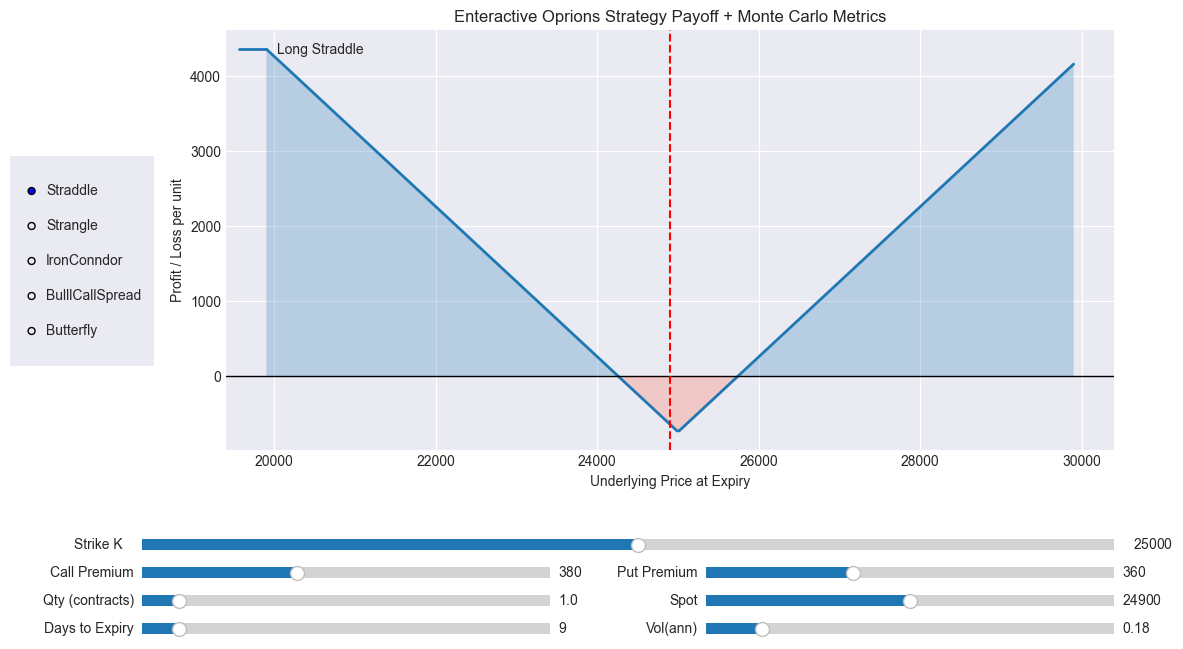

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider,Button,RadioButtons
from scipy.stats import norm


def call_payoff(s,k,premium=0.0,qty=1.0,long=True):
    """
    s: spot price \n
    k: strick price \n
    premium: one lot price \n
    qty: number of lots \n
    """
    payoff = np.maximum(s - k, 0) - premium
    return payoff * qty if long else -payoff * qty

def put_payoff(s,k,premium=0.0,qty=1.0,long=True):
    """
    s: spot price \n
    k: strick price \n
    premium: one lot price \n
    qty: number of lots \n
    """
    payoff = np.maximum(k - s, 0) - premium
    return payoff * qty if long else -payoff * qty

def combined_payoff(s, legs):
    total = np.zeros_like(s)
    for leg in legs:
        if leg['type'] == 'C':
            total += call_payoff(s,leg['K'],premium=leg['premium'],qty=leg['qty'],long=leg['long'])
        else:
            total += put_payoff(s,leg['K'],premium=leg['premium'],qty=leg['qty'],long=leg['long'])
    return total

##Monte Carlo GBM simulator for S_T

def simulate_st(S0,mu,sigma,T_days,n_sims=12000,seed=42):
    """
    S0: Spot price at t=0(current spopt price) \n
    mu: avg \n
    sigma: volitality \n
    T_days: days to Expiry \n
    n_sims: Number of simmulation \n
    seed : random state
    """
    np.random.seed(seed)
    T = max(T_days,0)/252.0
    if T == 0:
        return np.array([S0])
    drift = (mu - 0.5*sigma **2) * T
    diffusion = sigma *np.sqrt(T) * np.random.random(n_sims)
    ST = S0 * np.exp(drift + diffusion)
    return ST



def expected_matrics_via_mc(legs,S0,mu,sigma,T_days,n_sims=12000):
    ST = simulate_st(S0,mu,sigma,T_days,n_sims=12000,seed=42)
    sim_payoff = np.array([combined_payoff(np.array([s]),legs)[0] for s in ST])
    ev = sim_payoff.mean()
    prob_profit = (sim_payoff > 0).mean()
    median = np.median(sim_payoff)
    downside_pct = (sim_payoff < 0).mean()
    return {'ev':ev, 'prob_profit':prob_profit, 'median':median, 'downside_pct':downside_pct}

### Analytics helpers
def breakevens(S,payoff):
    signs = np.sign(payoff)
    idx = np.where(np.diff(signs) != 0)[0]
    be_points = []
    for i in idx:
        x0, x1 = S[i], S[i+1]
        y0, y1 = payoff[i], payoff[i+1]
        if(y1 -y0) == 0:
            be = x0
        else:
            be = x0 - y0 * (x1 - x0) / (y1 - y0)
        be_points.append(be)
    return be_points 

mu_default = 0.06
S0_default =  24900
strike_default = 25000
premium_call_default = 380.0
premium_put_default = 360.0
qty_default = 1.0
T_days_default = 9
sigma_default = 0.18

S_min_default = S0_default - 5000
S_max_default =  S0_default + 5000
S = np.linspace(S_min_default,S_max_default,400)

### Create initial legs (Straddle)
def make_straddle(K, p_call, p_put, qty):
    return [
        {'type':'C','K':K,'premium':p_call,'qty':qty,'long':True},
        {'type':'P','K':K,'premium':p_put,'qty':qty,'long':True}
    ]

### Plot and widgets setup
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize= (12,7))
plt.subplots_adjust(left=0.19, bottom=0.28, right=0.93)

### initial payoff line
legs = make_straddle(strike_default,premium_call_default,premium_put_default, qty_default)
payoff = combined_payoff(S,legs)
line_payoff, = ax.plot(S, payoff, lw=2, label ='Long Straddle')

ax.axhline(0,color='k',lw=1)
ax.set_xlabel("Underlying Price at Expiry")
ax.set_ylabel("Profit / Loss per unit")
ax.set_title("Enteractive Oprions Strategy Payoff + Monte Carlo Metrics")
ax.legend(loc='upper left')

### vertical spot line & annotatio text  postitions
vline = ax.axvline(S0_default, color='red', linestyle='--',lw=1.5)
spot_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va = 'top')
be_text = ax.text(0.02,0.88, "", transform=ax.transAxes, va = 'top')
mc_text = ax.text(0.02, 0.78, "", transform=ax.transAxes, va = 'top')

#filled areas
pos_fill = ax.fill_between(S, payoff, where=(payoff >= 0),interpolate=True, alpha=0.25)
neg_fill = ax.fill_between(S, payoff, where=(payoff < 0),interpolate=True, alpha=0.25, color='tomato')

# slider axes layout
axstrike = plt.axes([0.12,0.13,0.81,0.03])
axpcall = plt.axes([0.12,0.09,0.34,0.03])
axpput = plt.axes([0.59,0.09,0.34,0.03])
axqty = plt.axes([0.12,0.05,0.34,0.03])
axspot = plt.axes([0.59,0.05,0.34,0.03])
axT = plt.axes([0.12,0.01,0.34,0.03])
axvol = plt.axes([0.59,0.01,0.34,0.03])

s_strike = Slider(axstrike,'Strike K',S_min_default,S_max_default,valinit=strike_default,valstep=50)
s_pcall = Slider(axpcall, 'Call Premium', 0.0, 1000.0, valinit=premium_call_default)
s_pput = Slider(axpput, 'Put Premium', 0.0,1000.0, valinit=premium_put_default)
s_qty = Slider(axqty, 'Qty (contracts)', 0.1, 10.0, valinit=qty_default)
s_spot = Slider(axspot, 'Spot', S_min_default,S_max_default,valinit=S0_default)
s_T = Slider(axT, 'Days to Expiry', 1, 90, valinit=T_days_default,valstep=1)
s_vol = Slider(axvol, 'Vol(ann)', 0.05,1.0, valinit=sigma_default)


###Radiobuttons for strategy selection (mutually exclusive)
axradio = plt.axes([0.01,0.4,0.12,0.30])
radio = RadioButtons(axradio, ('Straddle','Strangle', 'IronConndor','BulllCallSpread','Butterfly'))
radio.set_active(0)

### Update logic
def build_strategy_from_radio(K, p_call, p_put, qty):
    strategy = radio.value_selected
    if strategy  == 'Straddle':
        return make_straddle(K,p_call,p_put,qty), 'Long Straddle'
    elif strategy == 'Strangle':
        Kput = max(1,K-400)
        Kcall = K + 400
        legs = [
            {'type':'C','K':Kcall,'premium':p_call*0.6,'qty':qty,'long':True},
            {'type':'P','K':Kput,'premium':p_put*0.6,'qty':qty,'long':True}
        ]
        return legs, f'Long Strangle({Kput}/{Kcall})'
    elif strategy == 'IrronCondor':
        legs = [
            
            {'type':'P','K':K-400,'premium':p_put*0.7,'qty':qty,'long':False},  #short put
            {'type':'P','K':K-800,'premium':p_put*0.3,'qty':qty,'long':True},  #long put
            {'type':'C','K':K-400,'premium':p_call*0.7,'qty':qty,'long':False}, #short call
            {'type':'C','K':K-800,'premium':p_call*0.3,'qty':qty,'long':True}  #long call
        ]
        return legs, 'Iron Condor (synthatic levels)'
    elif strategy == 'BullCallSpread':
        width = 400
        K_buy = max(1, K - int(width/2)) ##lower strike
        K_sell = K_buy + width  ## higher strike
        legs = [
            {'type':'C','K':K_buy,'premium':p_call*0.9,'qty':qty,'long':True}, #buy lower call
            {'type':'C','K':K_sell,'premium':p_call*0.5,'qty':qty,'long':False}  #sell higher call
        ]
        return legs, f'Bull call spreed ({K_buy}->{K_sell})'
    
    elif strategy == 'Butterfly':
        wing = 600
        K_low = K- wing
        K_mid = K
        K_high = K + wing
        legs = [
            {'type':'C','K':K_low,'premium':p_call*0.9,'qty':qty,'long':True},
            {'type':'C','K':K_mid,'premium':p_call*0.7,'qty':qty*2,'long':False},
            {'type':'C','K':K_high,'premium':p_call*0.9,'qty':qty,'long':True}
        ]
        return legs, f'Long Butterfly ({K_low},{K_mid},{K_high})'
    else:
        return make_straddle(K,p_call, p_put, qty), 'Long Straddle'
    
    
def update (val):
    K = s_strike.val
    p_call = s_pcall.val
    p_put = s_pput.val
    qty = s_qty.val
    spot_now = s_spot.val
    T_days = int(s_T.val)
    vol = s_vol.val
    current_legs, label = build_strategy_from_radio(K,p_call, p_put, qty)
    new_payoff = combined_payoff(S, current_legs)
    line_payoff.set_ydata(new_payoff)
    line_payoff.set_label(label)
    ax.legend(loc='upper right',frameon=True)

    ##update fills 
    global pos_fill, neg_fill
    try:
        pos_fill.remove()
        neg_fill.remove()
    except Exception:
        pass
    pos_fill = ax.fill_between(S,new_payoff, where=(new_payoff>=0),interpolate=True,alpha=0.25)
    neg_fill = ax.fill_between(S,new_payoff,where=(new_payoff<0),interpolate=True, alpha=0.25,color='tomato')


    ### Breakevens
    bes = breakevens(S,new_payoff)
    be_str = "Breakenen(s) : " +(", ".join([f"{b:.0f}" for b in bes]) if bes else "None")
    be_text.set_text(be_str)

    ### Monte Carlo analytics
    metrics = expected_matrics_via_mc(current_legs,spot_now,mu_default,vol,T_days,n_sims=12000)
    mc_str = (
        f" MC EV: {metrics['ev']: .1f}  "
        f"Prob(Profit) : {metrics['prob_profit']*100:.1f}% "
        f"Median: {metrics['median']:.1f}"
    )

    ### Set rich text properties for emphasis
    mc_text.set_text(mc_str)
    mc_text.set_fontsize(11)
    mc_text.set_fontweight('bold')
    mc_text.set_color("#24ADA4")
    mc_text.set_bbox(dict(
        facecolor = 'white', alpha = 0.9, edgecolor = "#475554", boxstyle='round,pad=0.3'
    ))
    vline.set_xdata([spot_now,spot_now])
    spot_text.set_text(f'Spot: {spot_now:.0f}   Strike K: {K:.0f}   Qty: {qty:.2f}')
    fig.canvas.draw_idle()


    ### connect widgets
    s_strike.on_changed(update)
    s_pcall.on_changed(update)
    s_pput.on_changed(update)
    s_qty.on_changed(update)
    s_spot.on_changed(update)
    s_T.on_changed(update)
    s_vol.on_changed(update)
    radio.on_clicked(lambda _: update(None))

    update(None)
    plt.show()
